# 💊 Una bacteria "agotada" escondía un antibiótico nuevo

Durante 80 años buscamos antibióticos en las mismas bacterias del suelo. Llegamos a creer que ya no quedaba nada nuevo ahí. **Nos equivocamos.**

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *A natural depsipeptide antibiotic binds the E-site of the bacterial ribosome*
**Revista:** Nature (2026) · **DOI:** [10.1038/s41586-026-10589-2](https://doi.org/10.1038/s41586-026-10589-2)
🎬 **Video:** Pendiente

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-06-manikomycin-antibiotico-ribosoma/notebook.ipynb)

## El contexto

La bacteria *Streptomyces rimosus* es una vieja conocida: de ella sacamos la oxitetraciclina, un antibiótico que llevamos décadas usando. Tan estudiada está que se daba por exprimida.

Usando una técnica de separación más fina —una que rescata los compuestos minoritarios que antes se pasaban por alto— el equipo encontró en esa misma bacteria una molécula nueva: la **manikomicina**.

Y lo interesante no es solo que sea nueva, sino *cómo* mata. Se pega al **sitio E** del ribosoma bacteriano (la fábrica de proteínas de la célula) y atasca el paso de la lectura genética. Es un punto que ningún antibiótico conocido había atacado antes, y funciona contra bacterias resistentes a casi todo lo demás.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CMAX_UG_ML = 9.13     # Pico de manikomicina en sangre (µg/ml), a los 30 min
MIC_BAJA   = 6.4      # Extremo bajo de la concentración que mata bacterias (µg/ml)
MIC_ALTA   = 32.0     # Extremo alto del rango de MIC reportado
DOSIS_GUSANOS = 64    # Concentración usada para tratar a los gusanos (µg/ml)

COLOR_MKM        = '#2563EB'   # Manikomicina (nuestra protagonista)
COLOR_SIN_TRATAR = '#DC2626'   # Infectado sin tratar
COLOR_POLIMIXINA = '#059669'   # Polimixina B (antibiótico de último recurso)
COLOR_SANO       = '#999999'   # Sin infectar (techo de referencia)

FUENTE = 'Fuente: Nature (2026), DOI 10.1038/s41586-026-10589-2 | Datos: Material suplementario'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

# Estilo CaM: local → /tmp → GitHub raw (Colab)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos
pk     = pd.read_csv('datos/farmacocinetica_mkm.csv')      # media/sd por tiempo
pk_raw = pd.read_csv('datos/farmacocinetica_mkm_raw.csv')  # cada ratón
surv   = pd.read_csv('datos/supervivencia_celegans.csv')   # Kaplan-Meier

print(f'Farmacocinética: {len(pk)} tiempos, {pk["n_ratones"].iloc[0]:.0f} ratones')
print(f'Supervivencia:   {surv["cepa"].nunique()} cepas × {surv["condicion"].nunique()} condiciones, hasta el día {surv["dia"].max()}')
print(f'Pico en sangre (Cmax): {pk["conc_media_ug_ml"].max():.2f} µg/ml a los {pk.loc[pk["conc_media_ug_ml"].idxmax(),"tiempo_h"]:.2g} h')

Farmacocinética: 7 tiempos, 3 ratones
Supervivencia:   2 cepas × 4 condiciones, hasta el día 7
Pico en sangre (Cmax): 9.13 µg/ml a los 0.5 h


Que mate bacterias en una placa de laboratorio es una cosa. ¿Pero salva a un animal infectado?

**Aquí está.**

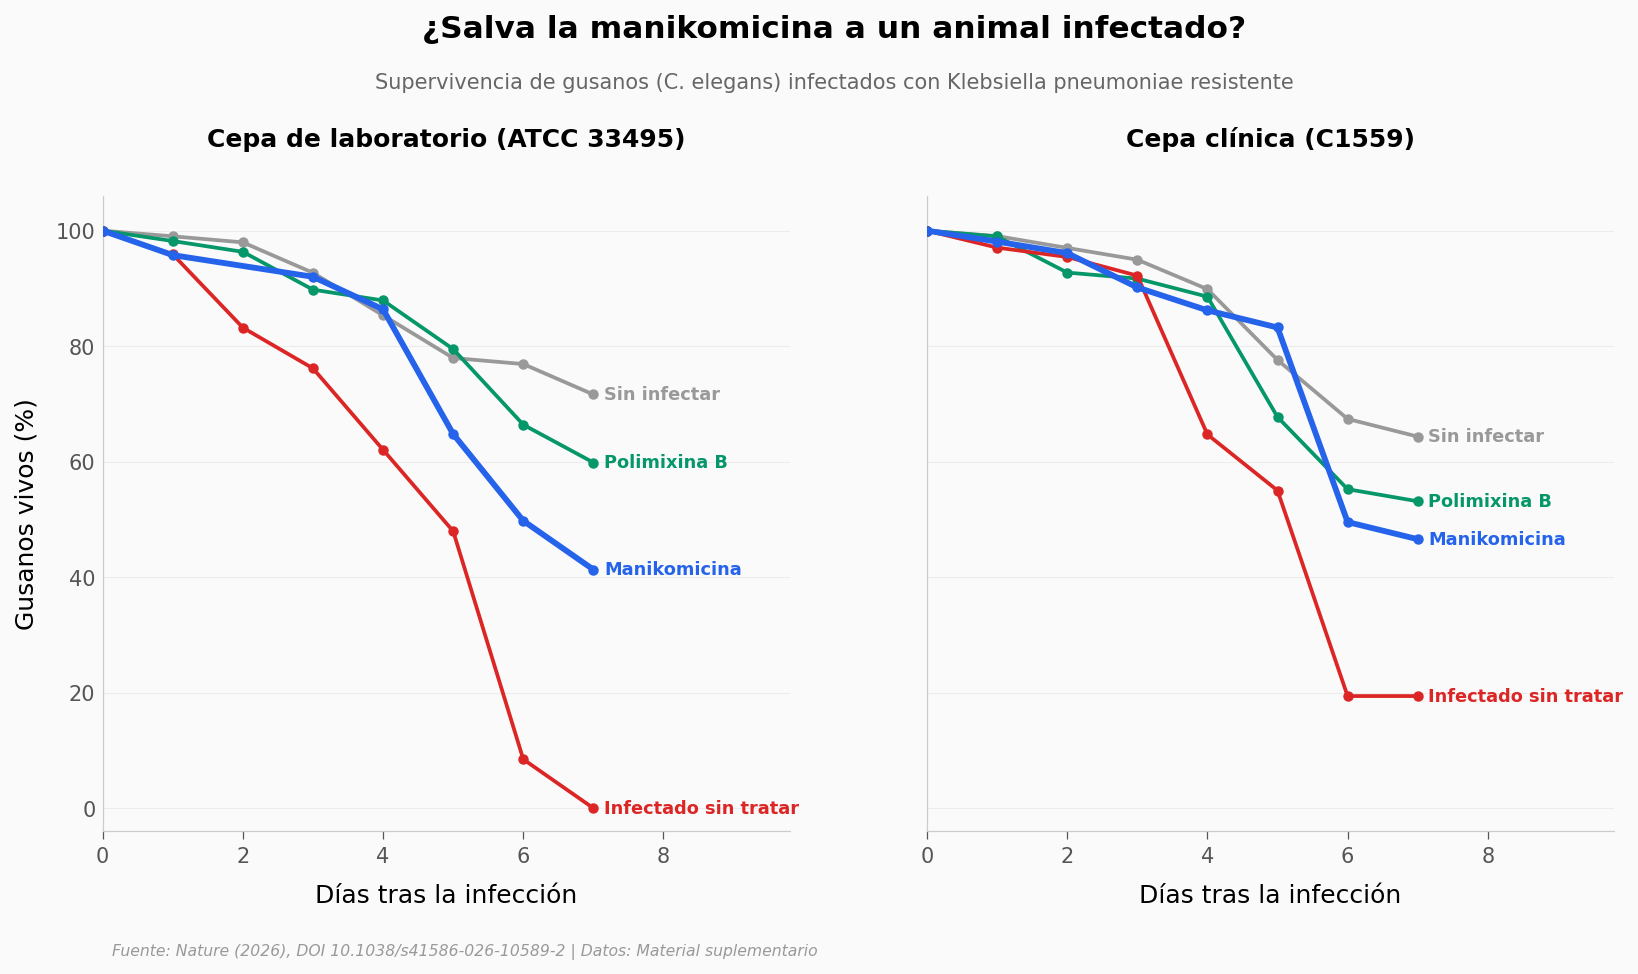

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

estilo = {
    'Uninfected':    ('Sin infectar',         COLOR_SANO),
    'PolymyxinB_25': ('Polimixina B',         COLOR_POLIMIXINA),
    'MKM_64':        ('Manikomicina',         COLOR_MKM),
    'DMSO':          ('Infectado sin tratar', COLOR_SIN_TRATAR),
}
cepas   = ['ATCC_33495', 'C1559']
titulos = ['Cepa de laboratorio (ATCC 33495)', 'Cepa clínica (C1559)']

for ax, cepa, titulo in zip(axes, cepas, titulos):
    sub = surv[surv['cepa'] == cepa]
    for cond, (label, color) in estilo.items():
        d = sub[sub['condicion'] == cond].sort_values('dia')
        lw = 2.8 if cond == 'MKM_64' else 1.8
        z  = 6 if cond == 'MKM_64' else 3
        ax.plot(d['dia'], d['supervivencia_pct'], color=color, linewidth=lw,
                marker='o', markersize=4, zorder=z)
        ax.text(d['dia'].iloc[-1] + 0.15, d['supervivencia_pct'].iloc[-1],
                label, color=color, fontsize=8.5, fontweight='bold', va='center')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Días tras la infección')
    ax.set_xlim(0, 9.8)
    ax.set_ylim(-4, 106)

axes[0].set_ylabel('Gusanos vivos (%)')
fig.suptitle('¿Salva la manikomicina a un animal infectado?',
             fontsize=15, fontweight='bold', y=1.10)
fig.text(0.5, 1.01, 'Supervivencia de gusanos (C. elegans) infectados con Klebsiella pneumoniae resistente',
         ha='center', fontsize=10, color='#666666')
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/supervivencia_curvas.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que dicen las curvas

Sin tratamiento, la infección es letal: en la cepa de laboratorio ningún gusano llega vivo al día 7. Con manikomicina, **4 de cada 10 sobreviven**.

El orden se repite en las dos cepas: arriba los sanos, después la polimixina B (el antibiótico de último recurso), debajo la manikomicina, y al fondo los infectados sin tratar. La manikomicina rescata —pero rescata *menos* que la polimixina B. No es un empate: es una molécula prometedora en una etapa muy temprana, no un fármaco terminado.

## Pero hay una trampa

Salvar gusanos no es lo mismo que salvar a un mamífero. Para servir en un cuerpo más grande, la molécula tiene que *quedarse* en la sangre el tiempo suficiente para alcanzar a las bacterias. Veamos qué le pasa a la manikomicina cuando se inyecta en un ratón.

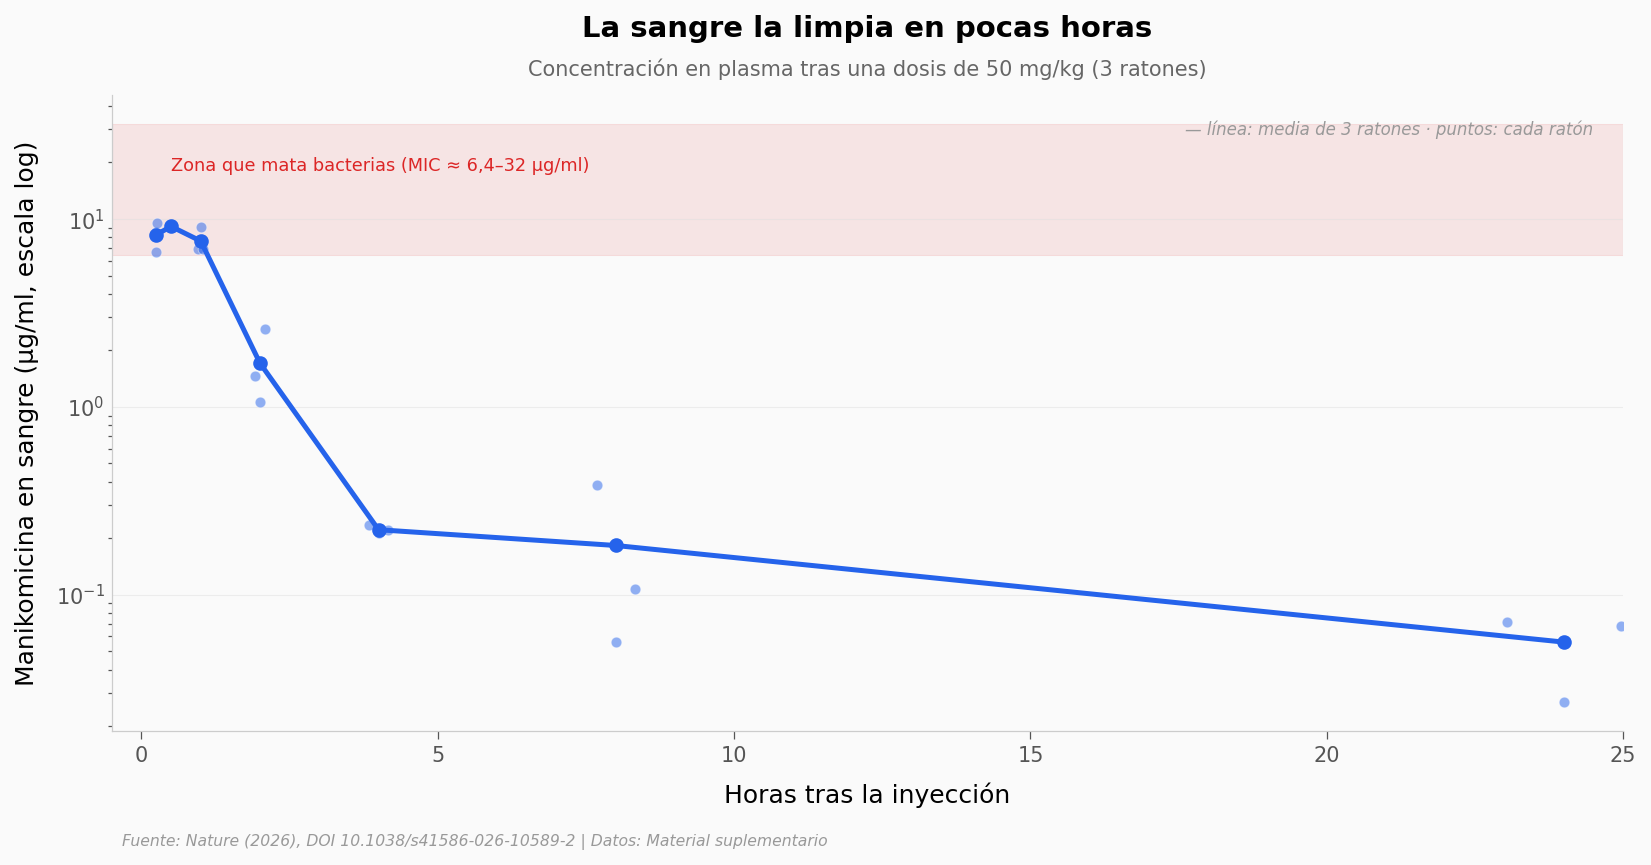

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Banda: concentración que mata bacterias (MIC)
ax.axhspan(MIC_BAJA, MIC_ALTA, color=COLOR_SIN_TRATAR, alpha=0.10, zorder=0)
ax.text(0.5, (MIC_BAJA + MIC_ALTA) / 2,
        'Zona que mata bacterias (MIC ≈ 6,4–32 µg/ml)',
        color=COLOR_SIN_TRATAR, fontsize=8.5, va='center', ha='left')

# Puntos crudos por ratón (jitter reproducible — regla 23)
np.random.seed(42)
for t in pk_raw['tiempo_h'].unique():
    vals = pk_raw[pk_raw['tiempo_h'] == t]['conc_ug_ml'].values
    xj = np.linspace(t * 0.96, t * 1.04, len(vals))
    ax.scatter(xj, vals, color=COLOR_MKM, s=26, alpha=0.5,
               edgecolors='white', linewidths=0.4, zorder=4)

# Curva media (los puntos por ratón muestran la dispersión real, n=3)
ax.plot(pk['tiempo_h'], pk['conc_media_ug_ml'], color=COLOR_MKM,
        linewidth=2.4, marker='o', markersize=6, zorder=5)

ax.set_yscale('log')
ax.set_xlabel('Horas tras la inyección')
ax.set_ylabel('Manikomicina en sangre (µg/ml, escala log)')
ax.set_xlim(-0.5, 25)
ax.set_title('La sangre la limpia en pocas horas', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Concentración en plasma tras una dosis de 50 mg/kg (3 ratones)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.96,
        '— línea: media de 3 ratones · puntos: cada ratón',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='top', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/farmacocinetica.png', dpi=200, bbox_inches='tight')
plt.show()

## Por eso, de momento, solo gusanos

La concentración sube a 9 µg/ml y se desploma: a las 4 horas queda apenas el **2,4 %** del pico. La manikomicina solo roza la zona donde mata bacterias, y por muy poco tiempo.

Eso encaja con una nota del propio paper: el primer modelo en ratón no mostró eficacia. La molécula mata bacterias, pero su vida corta en sangre es justo el tipo de obstáculo que hay que resolver antes de pensar en una persona. Por eso el equipo la presenta como un **punto de partida** para diseñar antibióticos, no como el próximo fármaco de farmacia.

## ¿Cuánto rescata, exactamente?

Pongámosle número al rescate, cepa por cepa, al día 7.

ATCC_33495: manikomicina vs sin tratar → Fisher p = 4.3e-13
C1559: manikomicina vs sin tratar → Fisher p = 3.1e-04


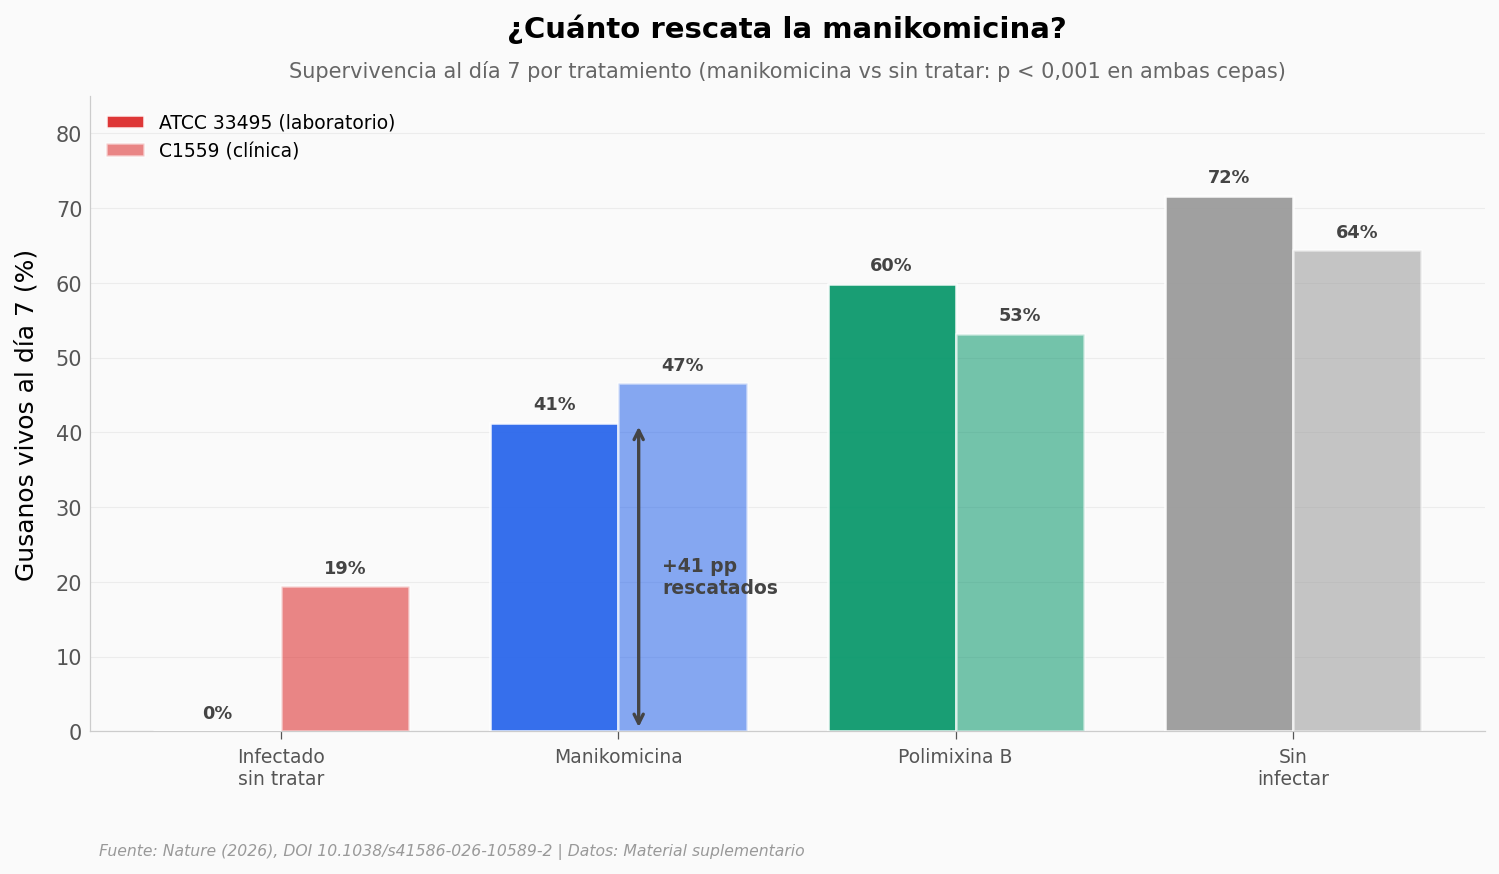

In [4]:
fig, ax = plt.subplots(figsize=(12, 5.5))

orden     = ['DMSO', 'MKM_64', 'PolymyxinB_25', 'Uninfected']
etiquetas = ['Infectado\nsin tratar', 'Manikomicina', 'Polimixina B', 'Sin\ninfectar']
colores   = [COLOR_SIN_TRATAR, COLOR_MKM, COLOR_POLIMIXINA, COLOR_SANO]
cepas     = ['ATCC_33495', 'C1559']
nombres   = ['ATCC 33495 (laboratorio)', 'C1559 (clínica)']

x = np.arange(len(orden))
width = 0.38
offsets = [-width / 2, width / 2]
alphas  = [0.92, 0.55]

d7 = surv[surv['dia'] == 7]
valores = {}
for i, cepa in enumerate(cepas):
    vals = [d7[(d7['cepa'] == cepa) & (d7['condicion'] == c)]['supervivencia_pct'].iloc[0] for c in orden]
    valores[cepa] = dict(zip(orden, vals))
    bars = ax.bar(x + offsets[i], vals, width, color=colores, alpha=alphas[i],
                  edgecolor='white', linewidth=1.2, zorder=3, label=nombres[i])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.8, f'{v:.0f}%',
                ha='center', fontsize=8.5, fontweight='bold', color='#444444')

# Flecha bidireccional del rescate (manikomicina vs sin tratar), cepa de laboratorio
xm = x[1] + offsets[0]
dmso0, mkm0 = valores['ATCC_33495']['DMSO'], valores['ATCC_33495']['MKM_64']
ax.annotate('', xy=(xm + 0.25, mkm0), xytext=(xm + 0.25, dmso0),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.6))
ax.text(xm + 0.32, (dmso0 + mkm0) / 2, f'+{mkm0 - dmso0:.0f} pp\nrescatados',
        fontsize=9, fontweight='bold', color='#444444', va='center')

# p-values (Fisher exacto, vivos/muertos al día 7, manikomicina vs sin tratar)
for i, cepa in enumerate(cepas):
    n_mkm  = surv[(surv.cepa == cepa) & (surv.condicion == 'MKM_64')]['n_gusanos'].iloc[0]
    n_dmso = surv[(surv.cepa == cepa) & (surv.condicion == 'DMSO')]['n_gusanos'].iloc[0]
    a = round(valores[cepa]['MKM_64'] / 100 * n_mkm); b = n_mkm - a
    c = round(valores[cepa]['DMSO']   / 100 * n_dmso); dd = n_dmso - c
    _, p = fisher_exact([[a, b], [c, dd]])
    print(f'{cepa}: manikomicina vs sin tratar → Fisher p = {p:.1e}')

ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=9)
ax.set_ylabel('Gusanos vivos al día 7 (%)')
ax.set_ylim(0, 85)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.set_title('¿Cuánto rescata la manikomicina?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Supervivencia al día 7 por tratamiento (manikomicina vs sin tratar: p < 0,001 en ambas cepas)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rescate_dia7.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| La manikomicina rescata gusanos infectados | ✅ | Laboratorio: 0 % → 41 % de supervivencia al día 7 (n=73 vs 118; Fisher p<0,001). Clínica: 19 % → 47 % (n=68 vs 105; razón de probabilidades ≈ 3,7; p<0,001) |
| Rescata menos que la polimixina B | ✅ | La polimixina B la supera en ambas cepas: +18 puntos (laboratorio) y +7 puntos (clínica). No hay empate |
| Se elimina rápido de la sangre | ✅ | Pico de 9,13 µg/ml a los 30 min; cae al 2,4 % (0,22 µg/ml) a las 4 h. Solo n=3 ratones |
| Ya sirve como antibiótico para personas | ⚠️ | La eficacia se probó solo en gusanos, no en mamíferos, y su vida en sangre es corta. El paper la enmarca como candidato (*lead*), no como fármaco |
| Ataca el sitio E del ribosoma (mecanismo nuevo) | ✅* | Lo afirma el paper a partir de estructuras por cryo-EM (PDB 9RJA y 9RFW). *No se reanaliza con datos en este notebook |

> **Limitaciones:** la farmacocinética viene de solo 3 ratones. La eficacia en un animal vivo se midió en *C. elegans*, no en mamíferos. El rango de MIC (~6,4–32 µg/ml) aparece de forma fragmentaria en el texto del paper. Las estructuras del ribosoma no se reanalizan aquí.

## Ahora tú

1. **¿Y antes del día 7?** El titular es la supervivencia al día 7, pero ¿en qué momento empiezan a separarse las curvas? Filtra `surv` por otro día y compara.
2. **¿Cuánto aguanta por encima de la MIC?** En la farmacocinética, ¿cuántas horas se mantiene la concentración sobre los 6,4 µg/ml? La celda de abajo te lo calcula —prueba cambiando el umbral.
3. **¿Importa la cepa?** La C1559 es clínica y la ATCC es de laboratorio. ¿El rescate de la manikomicina es parecido en las dos? Compara las dos barras azules.

In [5]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuántas horas se mantiene la manikomicina por encima de la concentración que mata bacterias?
umbral = MIC_BAJA  # µg/ml — extremo bajo de la MIC. Prueba con MIC_ALTA (32) para el caso más exigente

encima = pk[pk['conc_media_ug_ml'] >= umbral]
print(f'Tiempos con concentración ≥ {umbral} µg/ml:')
print(encima[['tiempo_h', 'conc_media_ug_ml']].to_string(index=False))

if len(encima):
    print(f'\nÚltimo tiempo por encima del umbral: {encima["tiempo_h"].max():.2g} h')
pct_4h = 100 * pk[pk.tiempo_h == 4]['conc_media_ug_ml'].iloc[0] / CMAX_UG_ML
print(f'A las 4 h ya solo queda el {pct_4h:.1f} % del pico.')

Tiempos con concentración ≥ 6.4 µg/ml:
 tiempo_h  conc_media_ug_ml
     0.25             8.258
     0.50             9.132
     1.00             7.633

Último tiempo por encima del umbral: 1 h
A las 4 h ya solo queda el 2.4 % del pico.


## Reproducibilidad

Todos los datos provienen del material suplementario del paper (Nature, mismo DOI). Notebook reproducible en el repositorio [Ciencia a Mordiscos / lab](https://github.com/Ciencia-a-Mordiscos/lab). Datos sujetos a los términos de Nature; código del notebook bajo licencia MIT.

## Fuentes

**Paper**: [A natural depsipeptide antibiotic binds the E-site of the bacterial ribosome](https://doi.org/10.1038/s41586-026-10589-2)  
*Nature, 2026-06-03*

**Source Data**: [Farmacocinética de manikomicina en ratón (MOESM3)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10589-2/MediaObjects/41586_2026_10589_MOESM3_ESM.xlsx)  
**Source Data**: [Supervivencia de C. elegans (MOESM6)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10589-2/MediaObjects/41586_2026_10589_MOESM6_ESM.xlsx)

**Referencias citadas**: [Estructuras cryo-EM del ribosoma — PDB 9RJA / 9RFW](https://www.rcsb.org/structure/9RJA)

*13 afirmaciones del notebook verificadas contra estas fuentes*